In [1]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit

In [2]:
current_directory = Path.cwd().parent
discharge_directory = Path.joinpath(current_directory, "Data Start Point")

compiled_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(discharge_directory, "points_of_interest.json")
RC_values_file_name = Path.joinpath(discharge_directory, "RC_values.csv")
ocv_soc_dict_file_name = Path.joinpath(discharge_directory, "ocv_soc_dict.csv")

output_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled (with SoC).csv")

In [3]:
points_of_interest = json.load(open(points_of_interest_file_name, 'r'))

In [4]:
compiled_df = pd.read_csv(compiled_file_name)

In [8]:
compiled_df.head()

,Translated Time,Translated Time (minutes),ADS Reading 1 (Smoothed and Offset),Calibrated Current 1,ADS Reading 2 (Smoothed and Offset),Calibrated Current 2,ADS Reading 3 (Smoothed),Calibrated Voltage,Charge Change
0,1000,0.016667,2.863429,0.008564,4.816303,0.014406,25542.0,58.202529,0.000000
1,1032,0.017200,-1.136571,-0.003399,4.816303,0.014406,25541.5,58.202529,0.000272
2,1064,0.017733,1.863429,0.005573,4.816303,0.014406,25541.0,58.197972,0.000248
3,1095,0.018250,1.863429,0.005573,4.816303,0.014406,25541.0,58.200251,0.000310
4,1126,0.018767,-3.136571,-0.009381,4.816303,0.014406,25541.0,58.200251,0.000194


In [9]:
compiled_df.tail()

,Translated Time,Translated Time (minutes),ADS Reading 1 (Smoothed and Offset),Calibrated Current 1,ADS Reading 2 (Smoothed and Offset),Calibrated Current 2,ADS Reading 3 (Smoothed),Calibrated Voltage,Charge Change
623037,31170698,519.511633,-4.3125,-0.012898,155.122554,0.464382,9316.0,21.22836,0.006998
623038,31170729,519.512150,-4.3125,-0.012898,155.122554,0.464382,9316.0,21.22836,0.006998
623039,31170760,519.512667,-4.3125,-0.012898,155.122554,0.464382,9316.0,21.22836,0.006998
623040,31170792,519.513200,-3.8125,-0.011403,154.622554,0.462884,9316.0,21.22836,0.007224
623041,31170823,519.513717,-3.3125,-0.009907,154.122554,0.461386,9316.0,21.22836,0.006998


In [10]:
if (str(compiled_df['Calibrated Current 2'].iloc[0]) != 'nan'):
    
    average_current = ((compiled_df['Calibrated Current 1'] + compiled_df['Calibrated Current 2']) / 2 + 
                   ((compiled_df['Calibrated Current 1'] + compiled_df['Calibrated Current 2']) / 2).shift(1)) / 2
else:
    print("Calibrated Current 2 is NaN, using Calibrated Current 1 only for charge calculation.")
    average_current = compiled_df['Calibrated Current 1']
print(str(compiled_df['Calibrated Current 2'].iloc[0]) + ", " + str(type(compiled_df['Calibrated Current 2'].iloc[0])))
average_current[average_current < 0] = 0
average_current = average_current.fillna(0)

delta_time = compiled_df['Translated Time'].diff() / 1000   # Convert ms to seconds
delta_time = delta_time.fillna(0)

compiled_df['Charge Change'] = average_current * delta_time

sensor_draw_estimate = 0.081

total_charge = compiled_df['Charge Change'].sum()
total_Ah = (total_charge / 3600) - sensor_draw_estimate

print(f"Total Charge: {total_charge:.4f} Coulombs")
print(f"Total Ah: {total_Ah:.4f} Ah")

0.0144055554860032, <class 'numpy.float64'>
Total Charge: 264420.2780 Coulombs
Total Ah: 73.3691 Ah


In [11]:
compiled_df['SoC'] = compiled_df['Charge Change'].cumsum()
compiled_df['SoC'] = (total_charge - compiled_df['SoC']) / total_charge * 100
compiled_df.head()

,Translated Time,Translated Time (minutes),ADS Reading 1 (Smoothed and Offset),Calibrated Current 1,ADS Reading 2 (Smoothed and Offset),Calibrated Current 2,ADS Reading 3 (Smoothed),Calibrated Voltage,Charge Change,SoC
0,1000,0.016667,2.863429,0.008564,4.816303,0.014406,25542.0,58.202529,0.000000,100.0
1,1032,0.017200,-1.136571,-0.003399,4.816303,0.014406,25541.5,58.202529,0.000272,100.0
2,1064,0.017733,1.863429,0.005573,4.816303,0.014406,25541.0,58.197972,0.000248,100.0
3,1095,0.018250,1.863429,0.005573,4.816303,0.014406,25541.0,58.200251,0.000310,100.0
4,1126,0.018767,-3.136571,-0.009381,4.816303,0.014406,25541.0,58.200251,0.000194,100.0


In [12]:
before_close = points_of_interest['before_close']
before_open = points_of_interest['before_open']
before_close['SoC'] = []
before_open['SoC'] = []
for index in before_close['index']:
    before_close['SoC'].append(compiled_df.at[index, 'SoC'])

for index in before_open['index']:
    before_open['SoC'].append(compiled_df.at[index, 'SoC'])

print(f"Before Close: {json.dumps(before_close)}")
print(f"Before Open: {json.dumps(before_open)}")
print(len(before_close['SoC']), len(before_close['voltage']))
print(len(before_open['SoC']), len(before_open['voltage']))

Before Close: {"index": [20, 32019, 94585, 157046, 205805, 246042, 279302, 318385, 376948, 423773, 467735, 512795, 554246, 612925], "time": [0.021642499999999967, 27.460005000000002, 74.65789333333333, 120.16813833333333, 162.80409583333332, 194.19948250000002, 220.98811499999996, 253.08190833333333, 297.7209833333333, 336.9117625, 381.5407566666667, 426.0909141666667, 466.5257066666666, 510.0161858333333], "voltage": [58.20104818239796, 57.04962158801021, 56.33274288903061, 55.404628794642875, 54.10098510841838, 53.1233093112245, 52.382162468112234, 51.80109422831633, 51.34786100127552, 50.839938998724506, 50.25340188137756, 49.443438329081644, 49.10300070153062, 46.79999999999999], "SoC": [99.99999502453794, 92.25061201649817, 84.90837154279616, 76.44521063511985, 68.84295597587344, 61.414986030621485, 54.98953049833726, 48.03839639442714, 40.19327438889128, 32.79414113152525, 25.197957132659006, 18.225643173763665, 11.22062464246806, 4.346957868813508]}
Before Open: {"index": [12852

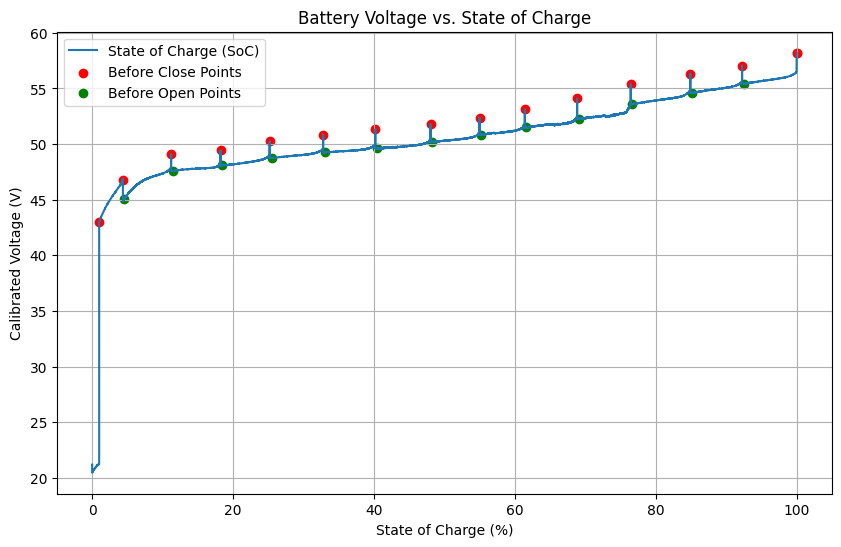

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(compiled_df['SoC'].iloc[:12694795], compiled_df['Calibrated Voltage'].iloc[:12694795], label='State of Charge (SoC)')
plt.scatter(before_close['SoC'], before_close['voltage'], color='red', label='Before Close Points')
plt.scatter(before_open['SoC'], before_open['voltage'], color='green', label='Before Open Points')
plt.xlabel('State of Charge (%)')
plt.ylabel('Calibrated Voltage (V)')
plt.title('Battery Voltage vs. State of Charge')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
print(len(compiled_df))

623042


In [15]:
# As the final OCV at SoC = 0
idx = -1

if before_close['index'][-1] != len(compiled_df) - 1:
    while compiled_df['Calibrated Voltage'].iloc[idx] < 40:
        idx -= 5
    last_point = compiled_df.iloc[idx]
    before_close['SoC'].append(last_point['SoC'])
    before_close['voltage'].append(last_point['Calibrated Voltage'])
    before_close['time'].append(last_point['Translated Time (minutes)'])
    before_close['index'].append(len(compiled_df) - idx)
    
    print(f"Added last point to before_close: SoC={last_point['SoC']}, Voltage={last_point['Calibrated Voltage']}, Index={len(compiled_df) - 1}")

Added last point to before_close: SoC=1.0012656512394937, Voltage=42.99677104591837, Index=623041


In [16]:
# Add the first point that is less than 100 soc to allow fitting for log later
idx = 0
if before_close['index'][0] != 0:
    while compiled_df['SoC'].iloc[idx] >= 100:
        idx += 5
    first_point = compiled_df.iloc[idx]
    
    before_close['SoC'].insert(0, first_point['SoC'])
    before_close['voltage'].insert(0, compiled_df['Calibrated Voltage'].iloc[0]) # but use the highest voltage at idx 0
    before_close['time'].insert(0, first_point['Translated Time (minutes)'])
    before_close['index'].insert(0, idx)
    
    print(f"Added first point to before_close: SoC={first_point['SoC']}, Voltage={first_point['Calibrated Voltage']}, Index={idx}")

Added first point to before_close: SoC=99.99999959237506, Voltage=58.20025063775511, Index=5


In [18]:
print(before_close)
print(before_open)

{'index': [5, 20, 32019, 94585, 157046, 205805, 246042, 279302, 318385, 376948, 423773, 467735, 512795, 554246, 612925, 627183], 'time': [np.float64(0.0192833333333333), 0.021642499999999967, 27.460005000000002, 74.65789333333333, 120.16813833333333, 162.80409583333332, 194.19948250000002, 220.98811499999996, 253.08190833333333, 297.7209833333333, 336.9117625, 381.5407566666667, 426.0909141666667, 466.5257066666666, 510.0161858333333, np.float64(515.4055333333333)], 'voltage': [np.float64(58.2025293367347), 58.20104818239796, 57.04962158801021, 56.33274288903061, 55.404628794642875, 54.10098510841838, 53.1233093112245, 52.382162468112234, 51.80109422831633, 51.34786100127552, 50.839938998724506, 50.25340188137756, 49.443438329081644, 49.10300070153062, 46.79999999999999, np.float64(42.99677104591837)], 'SoC': [np.float64(99.99999959237506), np.float64(99.99999502453794), np.float64(92.25061201649817), np.float64(84.90837154279616), np.float64(76.44521063511985), np.float64(68.842955975

In [42]:
ocv_model = lambda soc, a, b, c, d, e: a + b * soc + c * soc**2 + d * np.log(soc) + e * np.log(100 - soc)
ocv_model_parameters, covariance = curve_fit(ocv_model, before_close['SoC'], before_close['voltage'], p0=[0.0, 0.01, -0.0001, 0.1, 0.1])
a, b, c, d, e = ocv_model_parameters
print(f"Fitted OCV model parameters: a={a:.5f}, b={b:.5f}, c={c:.5f}, d={d:.5f}, e={e:.5f}")

Fitted OCV model parameters: a=46.07919, b=0.02428, c=0.00055, d=0.90413, e=0.00059


In [43]:
def filter_df(soc, ocv, index_to_rm=[]):
    new_soc = []
    new_ocv = []
    for i in range(len(soc)):
        if i not in index_to_rm:
            new_soc.append(soc[i])
            new_ocv.append(ocv[i])
    return new_soc, new_ocv

In [44]:
before_close['SoC'][-1] = np.float64(0.01)
before_close['voltage'][-1] = np.float64(42.0)
print(f"Before Close SoC: {before_close['SoC']}")
print(before_close['voltage'])

Before Close SoC: [np.float64(99.99999959237506), np.float64(99.99999502453794), np.float64(92.25061201649817), np.float64(84.90837154279616), np.float64(76.44521063511985), np.float64(68.84295597587344), np.float64(61.414986030621485), np.float64(54.98953049833726), np.float64(48.03839639442714), np.float64(40.19327438889128), np.float64(32.79414113152525), np.float64(25.197957132659006), np.float64(18.225643173763665), np.float64(11.22062464246806), np.float64(4.346957868813508), np.float64(0.01)]
[np.float64(58.2025293367347), 58.20104818239796, 57.04962158801021, 56.33274288903061, 55.404628794642875, 54.10098510841838, 53.1233093112245, 52.382162468112234, 51.80109422831633, 51.34786100127552, 50.839938998724506, 50.25340188137756, 49.443438329081644, 49.10300070153062, 46.79999999999999, np.float64(42.0)]


In [45]:
soc = np.flip(np.array(before_close['SoC'].copy()))
ocv = np.flip(np.array(before_close['voltage'].copy()))
print(f"Original SoC: {soc}")
print(f"Original OCV: {ocv}")

Original SoC: [1.00000000e-02 4.34695787e+00 1.12206246e+01 1.82256432e+01
 2.51979571e+01 3.27941411e+01 4.01932744e+01 4.80383964e+01
 5.49895305e+01 6.14149860e+01 6.88429560e+01 7.64452106e+01
 8.49083715e+01 9.22506120e+01 9.99999950e+01 9.99999996e+01]
Original OCV: [42.         46.8        49.1030007  49.44343833 50.25340188 50.839939
 51.347861   51.80109423 52.38216247 53.12330931 54.10098511 55.40462879
 56.33274289 57.04962159 58.20104818 58.20252934]


C:\Users\Kor\AppData\Local\Temp\ipykernel_22072\539547926.py:1: RuntimeWarning: divide by zero encountered in log
  ocv_model = lambda soc, a, b, c, d, e: a + b * soc + c * soc**2 + d * np.log(soc) + e * np.log(100 - soc)


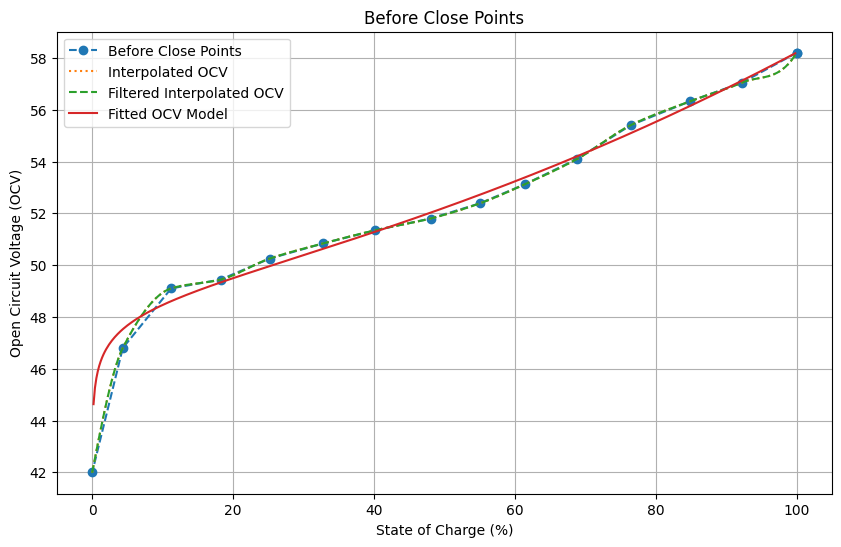

In [46]:
soc = np.flip(np.array(before_close['SoC'].copy()))
ocv = np.flip(np.array(before_close['voltage'].copy()))
""" soc = soc[:-1]
ocv = ocv[:-1]
soc = soc[:-3]
ocv = ocv[:-3] """


soc_smooth = np.linspace(0, 100, 500)

piecewise_cubic_interp = PchipInterpolator(soc, ocv)
piecewise_cubic_spline_ocv_smooth = piecewise_cubic_interp(soc_smooth)

filtered_piecewise_cubic_interp = PchipInterpolator(soc, ocv)
filtered_piecewise_cubic_spline_ocv_smooth = filtered_piecewise_cubic_interp(soc_smooth)

cubic_spline_interp = make_interp_spline(soc, ocv)
cubic_spline_ocv_smooth = cubic_spline_interp(soc_smooth)

filtered_cubic_spline_interp = make_interp_spline(*filter_df(soc, ocv, index_to_rm=[2]))
filtered_cubic_spline_ocv_smooth = filtered_cubic_spline_interp(soc_smooth)

plt.figure(figsize=(10, 6))
plt.plot(before_close['SoC'], before_close['voltage'], label='Before Close Points', linestyle='--', marker='o')
plt.plot(soc_smooth, piecewise_cubic_spline_ocv_smooth, label='Interpolated OCV', linestyle=':')
#plt.plot(soc_smooth, cubic_spline_ocv_smooth, label='Cubic Spline OCV', linestyle=':')

plt.plot(soc_smooth, filtered_piecewise_cubic_spline_ocv_smooth, label='Filtered Interpolated OCV', linestyle='--')
#plt.plot(soc_smooth, filtered_cubic_spline_ocv_smooth, label='Filtered Cubic Spline OCV', linestyle='--')

plt.plot(soc_smooth, ocv_model(soc_smooth, *ocv_model_parameters), label='Fitted OCV Model', linestyle='-')

plt.xlabel('State of Charge (%)')
plt.ylabel('Open Circuit Voltage (OCV)')
plt.title('Before Close Points')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Piecewise Function

print("Function: f(x) = c0*(x-x_i)^3 + c1*(x-x_i)^2 + c2*(x-x_i) + c3 for x in [x_i, x_{i+1}]")
knots = piecewise_cubic_interp.x
coef = piecewise_cubic_interp.c
intervals = len(coef[0])
print(f"Total number of intervals: {intervals}")
for i in range(intervals):
    print(f"Interval {i}:\tx in [{knots[i]}, {knots[i+1]}]")
    print(f"\t\tCoefficients: c0={coef[0][i]}, c1={coef[1][i]}, c2={coef[2][i]}, c3={coef[3][i]}")

Function: f(x) = c0*(x-x_i)^3 + c1*(x-x_i)^2 + c2*(x-x_i) + c3 for x in [x_i, x_{i+1}]
Total number of intervals: 15
Interval 0:	x in [0.01, 4.346957868813508]
		Coefficients: c0=-0.0002993049749830738, c1=0.006614619282911033, c2=0.0, c3=46.7
Interval 1:	x in [4.346957868813508, 11.22062464246806]
		Coefficients: c0=-0.011524942277368899, c1=0.12207220431153447, c2=0.04048558569723542, c3=46.79999999999999
Interval 2:	x in [11.22062464246806, 18.225643173763665]
		Coefficients: c0=0.0011501593379519123, c1=-0.013265546181622052, c2=0.08508585524317702, c3=49.10300070153062
Interval 3:	x in [18.225643173763665, 25.197957132659006]
		Coefficients: c0=-0.001455372360451597, c1=0.016976830919265825, c2=0.06855099981118405, c3=49.443438329081644
Interval 4:	x in [25.197957132659006, 32.79414113152525]
		Coefficients: c0=0.00019525268556858455, c1=-0.003565948341867014, c2=0.09303583347254729, c3=50.25340188137756
Interval 5:	x in [32.79414113152525, 40.19327438889128]
		Coefficients: c0=-3

In [118]:
knots = piecewise_cubic_interp.x
coef = piecewise_cubic_interp.c
intervals = len(coef[0])
print(f"Total number of intervals: {intervals}")
for i in range(intervals):
    print(f"Interval {i}: f(x) = {coef[0][i]} * (x-{knots[i]})**3 + {coef[1][i]} * (x-{knots[i]})**2 + {coef[2][i]} * (x-{knots[i]}) + {coef[3][i]} \n\tfor x in [{knots[i]}, {knots[i+1]}]")
    


Total number of intervals: 9
Interval 0: f(x) = -0.0011977536814397891 * (x-0.01)**3 + 0.022338510044358523 * (x-0.01)**2 + 0.032334000247653 * (x-0.01) + 46.7 
	for x in [0.01, 5.296208341644136]
Interval 1: f(x) = -0.004208076596082593 * (x-5.296208341644136)**3 + 0.06366283502507064 * (x-5.296208341644136)**2 + 0.1680959548161825 * (x-5.296208341644136) + 47.3182220187686 
	for x in [5.296208341644136, 15.868771756896077]
Interval 2: f(x) = 0.00015516979818638413 * (x-15.868771756896077)**3 + -0.0056387129751881305 * (x-15.868771756896077)**2 + 0.10312966761980084 * (x-15.868771756896077) + 51.23853183794919 
	for x in [15.868771756896077, 27.089915337392302]
Interval 3: f(x) = -7.475746492593356e-05 * (x-27.089915337392302)**3 + -5.1576926868205134e-05 * (x-27.089915337392302)**2 + 0.03519823116411907 * (x-27.089915337392302) + 51.905010757610434 
	for x in [27.089915337392302, 38.440125754695394]
Interval 4: f(x) = 2.8957502305018784e-05 * (x-38.440125754695394)**3 + -0.0005292813

In [119]:
# 2 options: Reverse each interval function to get SoC from OCV or a dictionary of OCV to SoC values for each point ~1000 interval.

C:\Users\Kor\AppData\Local\Temp\ipykernel_22072\933564224.py:2: RuntimeWarning: divide by zero encountered in log
  ocv_model = lambda soc, a, b, c, d, e: a + b * soc + c * soc**2 + d * np.log(soc) + e * np.log(100 - soc)


     SoC        OCV
0  0.000  39.836433
1  0.001  39.836433
2  0.002  40.463154
3  0.003  40.829772
4  0.004  41.089898
Lowest voltage: 39.83643308839722
Highest voltage: 58.20749911685556


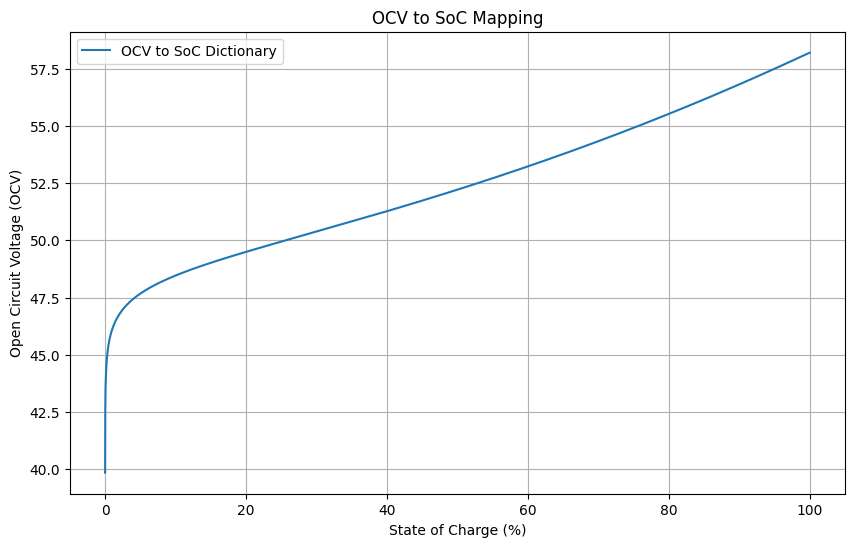

In [63]:
# Option 2: Faster O(1), but takes ~3000kb of data for 3 dp precision. 
# Not suitable for microcontroller but can be used for RPi

factor = 3 # Number of dp
array_interval = factor + 2 # Additional 2 for 0 - 100% SoC
ocv_soc_dict = {}
ocv_intervals = np.linspace(0, 100, 10**array_interval + 1)
for ocv_value in ocv_intervals:
    soc_value = ocv_model(ocv_value, *ocv_model_parameters)
    #soc_value = filtered_piecewise_cubic_interp(ocv_value)
    ocv_soc_dict[round(ocv_value, factor+2)] = soc_value.item()

output_df = pd.DataFrame({
    "SoC": list(ocv_soc_dict.keys()),
    "OCV": list(ocv_soc_dict.values())
})

output_df.loc[0, 'OCV'] = output_df['OCV'][1]
output_df.loc[len(output_df) - 1, 'OCV'] = output_df['OCV'][len(output_df) - 2]
print(output_df.head())

print(f"Lowest voltage: {output_df['OCV'].min()}")
print(f"Highest voltage: {output_df['OCV'].max()}")

plt.figure(figsize=(10, 6))
plt.plot(output_df['SoC'], output_df['OCV'], label='OCV to SoC Dictionary', linestyle='-')
plt.xlabel('State of Charge (%)')
plt.ylabel('Open Circuit Voltage (OCV)')
plt.title('OCV to SoC Mapping')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
output_df.to_csv(ocv_soc_dict_file_name, index=False)
print(f"Saved OCV to SoC dictionary with {len(ocv_soc_dict)} entries to {ocv_soc_dict_file_name}")
print(f"To use, get the ceiling of voltage reading to {factor} decimal places and look up corresponding SoC value in the dictionary.")

Saved OCV to SoC dictionary with 100001 entries to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\ocv_soc_dict.csv
To use, get the ceiling of voltage reading to 3 decimal places and look up corresponding SoC value in the dictionary.


In [130]:
compiled_df.to_csv(output_file_name, index=False)